# Task 9: Anchor-Free Object Detection Loss (CIoU Bounding Box Loss)

Calculate IoU loss between predicted and ground-truth bounding boxes.

In [1]:
import torch
import matplotlib.pyplot as plt

### 1. IoU (Intersection over Union) Calculation

In [2]:
# Box format: [x1, y1, x2, y2]
pred_box = torch.tensor([10.0, 10.0, 50.0, 50.0], requires_grad=True)
target_box = torch.tensor([15.0, 15.0, 55.0, 55.0])

# Intersection Box
ix1 = torch.max(pred_box[0], target_box[0])
iy1 = torch.max(pred_box[1], target_box[1])
ix2 = torch.min(pred_box[2], target_box[2])
iy2 = torch.min(pred_box[3], target_box[3])

inter_area = torch.clamp(ix2 - ix1, min=0) * torch.clamp(iy2 - iy1, min=0)
pred_area = (pred_box[2] - pred_box[0]) * (pred_box[3] - pred_box[1])
target_area = (target_box[2] - target_box[0]) * (target_box[3] - target_box[1])
union_area = pred_area + target_area - inter_area

iou = inter_area / union_area
box_loss = 1.0 - iou
print(f'IoU Score: {iou.item():.4f} | Box Regression Loss: {box_loss.item():.4f}')

IoU Score: 0.6203 | Box Regression Loss: 0.3797


### 2. Plot Bounding Boxes

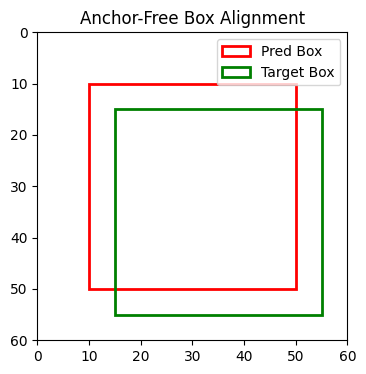

In [3]:
plt.figure(figsize=(4, 4))
p = pred_box.detach().numpy()
t = target_box.numpy()
plt.gca().add_patch(plt.Rectangle((p[0], p[1]), p[2]-p[0], p[3]-p[1], fill=False, color='red', lw=2, label='Pred Box'))
plt.gca().add_patch(plt.Rectangle((t[0], t[1]), t[2]-t[0], t[3]-t[1], fill=False, color='green', lw=2, label='Target Box'))
plt.xlim(0, 60)
plt.ylim(0, 60)
plt.gca().invert_yaxis()
plt.legend()
plt.title('Anchor-Free Box Alignment')
plt.show()